In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import BinaryClassificationMetrics
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import col, when

In [ ]:
# Step 2: Load the dataset
file_path = "/FileStore/tables/Loan_prediction_dataset.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

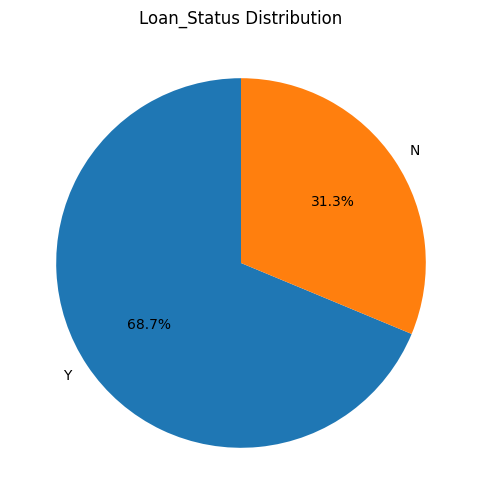

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your PySpark DataFrame
loan_status_counts = df.groupBy("Loan_Status").count().toPandas()

# Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(loan_status_counts['count'], labels=loan_status_counts['Loan_Status'], autopct='%1.1f%%', startangle=90)
plt.title('Loan_Status Distribution')
plt.show()


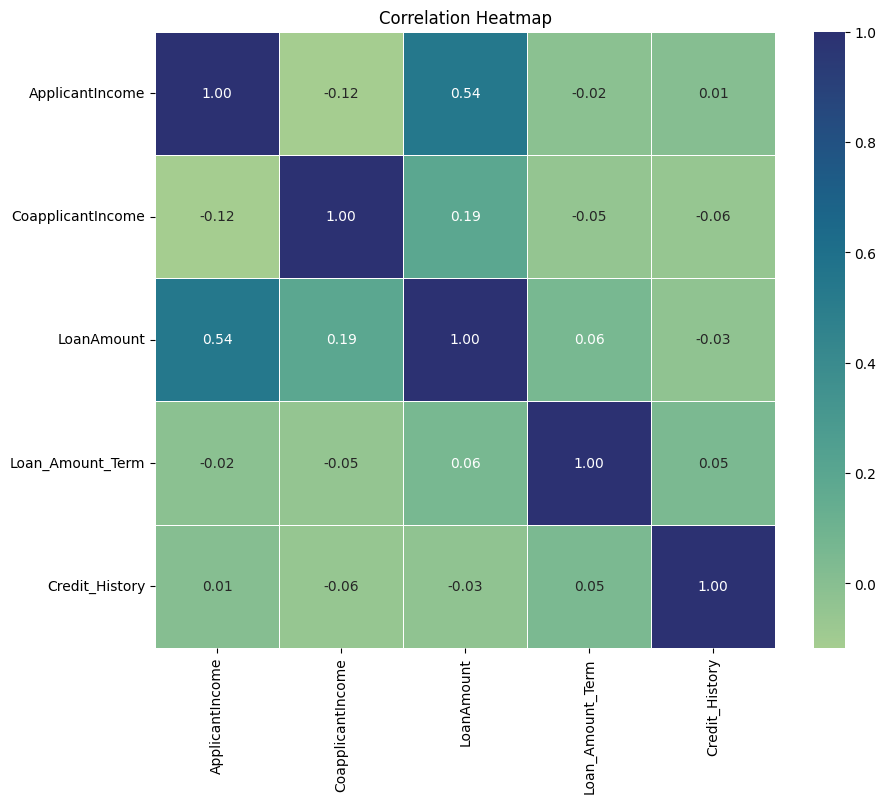

In [ ]:
# Selecting relevant numeric columns
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

# Dropping null values and selecting numeric columns
numeric_df = df.select(*numeric_cols).na.drop()

# Convert PySpark DataFrame to Pandas DataFrame
pandas_df = numeric_df.toPandas()

# Calculate correlation matrix
correlation_matrix = pandas_df.corr()

# Create a heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="crest", fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Step 3: Transform RDD
selected_columns = ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']
df = df.select(*selected_columns)


In [ ]:
# Handle null values
df = df.fillna(0, subset=['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area'])

In [ ]:
# Define categorical columns
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

# Create stages for StringIndexer and OneHotEncoder
indexers = [StringIndexer(inputCol=col, outputCol=f"{col}_index", handleInvalid="keep") for col in categorical_cols]
encoder = [OneHotEncoder(inputCols=[f"{col}_index"], outputCols=[f"{col}_encoded"]) for col in categorical_cols]

# Create a pipeline
pipeline = Pipeline(stages=indexers + encoder)

# Fit and transform the data
df = pipeline.fit(df).transform(df)

# Drop the original string columns and the index columns
df = df.drop(*categorical_cols).drop(*[f"{col}_index" for col in categorical_cols])

# Display schema
df.printSchema()


root
 |-- Loan_ID: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- ApplicantIncome: integer (nullable = true)
 |-- CoapplicantIncome: double (nullable = false)
 |-- LoanAmount: integer (nullable = true)
 |-- Loan_Amount_Term: integer (nullable = true)
 |-- Credit_History: integer (nullable = true)
 |-- Loan_Status: string (nullable = true)
 |-- Gender_encoded: vector (nullable = true)
 |-- Married_encoded: vector (nullable = true)
 |-- Education_encoded: vector (nullable = true)
 |-- Self_Employed_encoded: vector (nullable = true)
 |-- Property_Area_encoded: vector (nullable = true)



In [ ]:
# Centering and Scaling
assembler = VectorAssembler(inputCols=['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History',
                                       'Gender_encoded', 'Married_encoded', 'Education_encoded', 'Self_Employed_encoded', 'Property_Area_encoded'],
                            outputCol="features")
df = assembler.transform(df)

# Standard Scaling
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(df)
df = scaler_model.transform(df)


In [ ]:
# Convert "Loan_Status" to a numeric column
label_indexer = StringIndexer(inputCol="Loan_Status", outputCol="label").fit(df)
df = label_indexer.transform(df)

In [ ]:
# 5. Split training and testing
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)


In [ ]:
# 6. Create model (Random Forest Classifier)
rf_classifier = RandomForestClassifier(labelCol="label", featuresCol="scaled_features", numTrees=10)
rf_model = rf_classifier.fit(train_data)

# 7. Perform predictions
predictions = rf_model.transform(test_data)

# Display predictions
predictions.select("label", "prediction", "probability").show()


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.68950746459656...|
|  0.0|       0.0|[0.81457903447179...|
|  0.0|       0.0|[0.80827481522786...|
|  1.0|       0.0|[0.84827845620221...|
|  0.0|       0.0|[0.79340192795789...|
|  1.0|       1.0|[0.39688021444343...|
|  0.0|       0.0|[0.83176506400185...|
|  0.0|       0.0|[0.83964336320397...|
|  0.0|       0.0|[0.65015548726932...|
|  0.0|       0.0|[0.81570595349832...|
|  0.0|       0.0|[0.77782445970365...|
|  0.0|       0.0|[0.84846933335277...|
|  0.0|       0.0|[0.82923604770508...|
|  0.0|       0.0|[0.84867486383224...|
|  1.0|       1.0|[0.31475108225108...|
|  1.0|       1.0|[0.44878645886997...|
|  1.0|       0.0|[0.73258073907965...|
|  0.0|       0.0|[0.73753324867779...|
|  1.0|       1.0|[0.36259531633025...|
|  0.0|       0.0|[0.86913795152531...|
+-----+----------+--------------------+
only showing top 20 rows



In [ ]:
# 8. Create model (Logistic Regression)
lr_classifier = LogisticRegression(labelCol="label", featuresCol="scaled_features", maxIter=10)
lr_model = lr_classifier.fit(train_data)

# 9. Perform predictions with Logistic Regression
lr_predictions = lr_model.transform(test_data)

# Display predictions for Logistic Regression
lr_predictions.select("label", "prediction", "probability").show()


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.82391808587513...|
|  0.0|       0.0|[0.76076904877314...|
|  0.0|       0.0|[0.80884723949649...|
|  1.0|       0.0|[0.72935776396274...|
|  0.0|       0.0|[0.87439762755145...|
|  1.0|       1.0|[0.21730126875358...|
|  0.0|       0.0|[0.87957483189820...|
|  0.0|       0.0|[0.82492288412341...|
|  0.0|       0.0|[0.74087977136511...|
|  0.0|       0.0|[0.82749998983242...|
|  0.0|       0.0|[0.81709197547377...|
|  0.0|       0.0|[0.81382323030355...|
|  0.0|       0.0|[0.82522443867751...|
|  0.0|       0.0|[0.88557798997630...|
|  1.0|       1.0|[0.26643813467904...|
|  1.0|       1.0|[0.36438750299377...|
|  1.0|       0.0|[0.80786477462473...|
|  0.0|       0.0|[0.74865377009883...|
|  1.0|       1.0|[0.26892613212391...|
|  0.0|       0.0|[0.87615364789007...|
+-----+----------+--------------------+
only showing top 20 rows



In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 10. Evaluate Random Forest Classifier
rf_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
rf_accuracy = rf_evaluator.evaluate(predictions)
print(f"Accuracy of Random Forest Classifier: {rf_accuracy}")

# Additional metrics for Random Forest
rf_precision = rf_evaluator.evaluate(predictions, {rf_evaluator.metricName: "weightedPrecision"})
rf_recall = rf_evaluator.evaluate(predictions, {rf_evaluator.metricName: "weightedRecall"})
rf_f1 = rf_evaluator.evaluate(predictions, {rf_evaluator.metricName: "f1"})

print(f"Precision of Random Forest Classifier: {rf_precision}")
print(f"Recall of Random Forest Classifier: {rf_recall}")
print(f"F1 Score of Random Forest Classifier: {rf_f1}")


Accuracy of Random Forest Classifier: 0.7628865979381443
Precision of Random Forest Classifier: 0.7695876288659793
Recall of Random Forest Classifier: 0.7628865979381443
F1 Score of Random Forest Classifier: 0.7501876855776279


In [ ]:
# 11. Evaluate Logistic Regression
lr_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
lr_accuracy = lr_evaluator.evaluate(lr_predictions)
print(f"Accuracy of Logistic Regression: {lr_accuracy}")

# Additional metrics for Logistic Regression
lr_precision = lr_evaluator.evaluate(lr_predictions, {lr_evaluator.metricName: "weightedPrecision"})
lr_recall = lr_evaluator.evaluate(lr_predictions, {lr_evaluator.metricName: "weightedRecall"})
lr_f1 = lr_evaluator.evaluate(lr_predictions, {lr_evaluator.metricName: "f1"})

print(f"Precision of Logistic Regression: {lr_precision}")
print(f"Recall of Logistic Regression: {lr_recall}")
print(f"F1 Score of Logistic Regression: {lr_f1}")

Accuracy of Logistic Regression: 0.7525773195876289
Precision of Logistic Regression: 0.7553919871329484
Recall of Logistic Regression: 0.7525773195876289
F1 Score of Logistic Regression: 0.7408009516256938


Area under ROC curve: 0.7870205173951831
Area under ROC curve (Logistic Regression): 0.8180196253345231


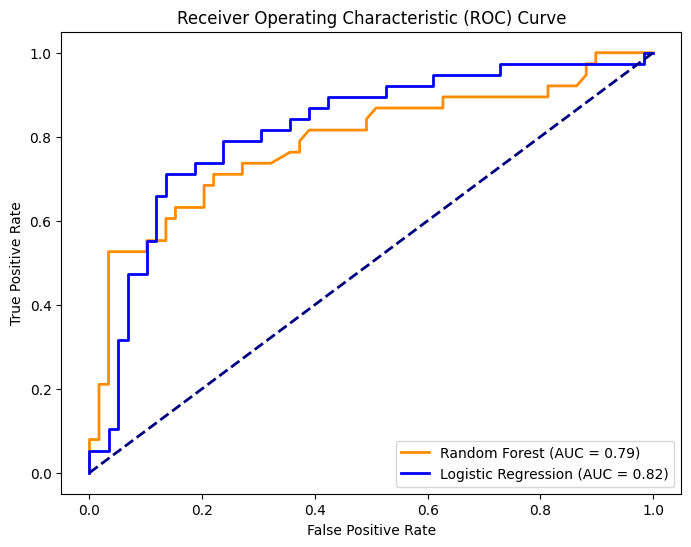

In [ ]:
from sklearn.metrics import roc_curve

# Evaluate the model
evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)
print(f"Area under ROC curve: {auc}")

# Evaluate the Logistic Regression model
lr_auc = evaluator.evaluate(lr_predictions)
print(f"Area under ROC curve (Logistic Regression): {lr_auc}")

# Extract probabilities for ROC curve
rf_probabilities = predictions.select("probability", "label").rdd.map(lambda row: (float(row["probability"][1]), float(row["label"])))
lr_probabilities = lr_predictions.select("probability", "label").rdd.map(lambda row: (float(row["probability"][1]), float(row["label"])))

# Calculate ROC curve points
rf_roc_curve = rf_probabilities.collect()
lr_roc_curve = lr_probabilities.collect()

# Extract FPR (False Positive Rate) and TPR (True Positive Rate)
fpr_rf, tpr_rf, _ = roc_curve([label for _, label in rf_roc_curve], [prob for prob, _ in rf_roc_curve])
fpr_lr, tpr_lr, _ = roc_curve([label for _, label in lr_roc_curve], [prob for prob, _ in lr_roc_curve])

# Calculate AUCs
roc_auc_rf = auc
roc_auc_lr = lr_auc

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

/databricks/spark/python/pyspark/sql/context.py:166: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


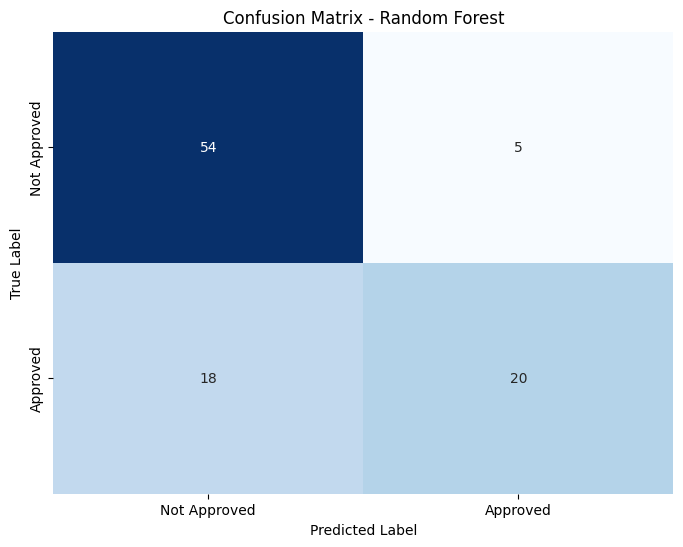

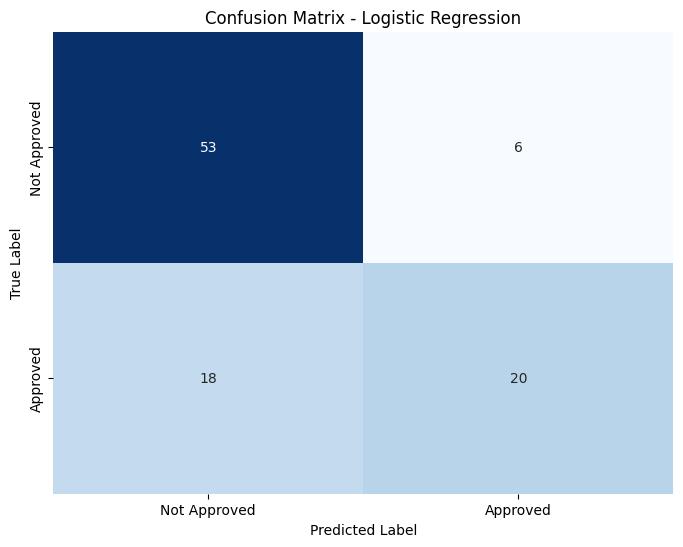

In [ ]:
from pyspark.mllib.evaluation import MulticlassMetrics
import seaborn as sns
import matplotlib.pyplot as plt

# Convert predictions to RDD for MulticlassMetrics
prediction_and_label_rf = predictions.select("prediction", "label").rdd.map(lambda row: (float(row["prediction"]), float(row["label"])))
prediction_and_label_lr = lr_predictions.select("prediction", "label").rdd.map(lambda row: (float(row["prediction"]), float(row["label"])))

# Confusion Matrix for Random Forest
metrics_rf = MulticlassMetrics(prediction_and_label_rf)
confusion_matrix_rf = metrics_rf.confusionMatrix().toArray()

# Confusion Matrix for Logistic Regression
metrics_lr = MulticlassMetrics(prediction_and_label_lr)
confusion_matrix_lr = metrics_lr.confusionMatrix().toArray()

# Plot Confusion Matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_rf, annot=True, fmt="g", cmap="Blues", cbar=False,
            xticklabels=["Not Approved", "Approved"],
            yticklabels=["Not Approved", "Approved"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Plot Confusion Matrix for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_lr, annot=True, fmt="g", cmap="Blues", cbar=False,
            xticklabels=["Not Approved", "Approved"],
            yticklabels=["Not Approved", "Approved"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Random Forest Classifier Metrics:
              precision    recall  f1-score   support

         0.0       0.75      0.92      0.82        59
         1.0       0.80      0.53      0.63        38

    accuracy                           0.76        97
   macro avg       0.78      0.72      0.73        97
weighted avg       0.77      0.76      0.75        97

Confusion Matrix:
[[54  5]
 [18 20]]

Logistic Regression Metrics:
              precision    recall  f1-score   support

         0.0       0.75      0.90      0.82        59
         1.0       0.77      0.53      0.62        38

    accuracy                           0.75        97
   macro avg       0.76      0.71      0.72        97
weighted avg       0.76      0.75      0.74        97

Confusion Matrix:
[[53  6]
 [18 20]]


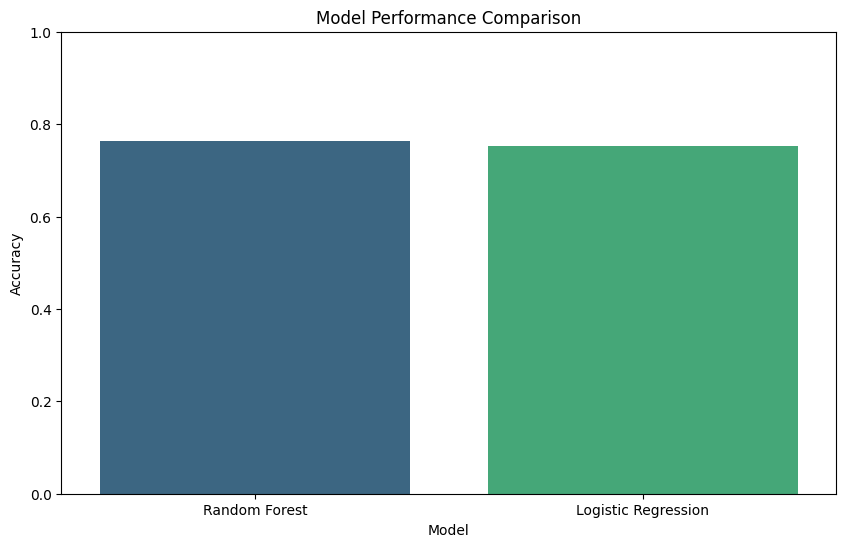

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Function to calculate and display classification report
def display_classification_report(predictions):
    y_true = predictions.select("label").toPandas()
    y_pred = predictions.select("prediction").toPandas()
    report = classification_report(y_true, y_pred)
    print(report)

# Function to calculate and display confusion matrix
def display_confusion_matrix(predictions):
    y_true = predictions.select("label").toPandas()
    y_pred = predictions.select("prediction").toPandas()
    cm = confusion_matrix(y_true, y_pred, labels=[0.0, 1.0])
    print("Confusion Matrix:")
    print(cm)

# Evaluate Random Forest model
rf_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
rf_accuracy = rf_evaluator.evaluate(predictions)

# Evaluate Logistic Regression model
lr_accuracy = lr_evaluator.evaluate(lr_predictions)

# Create a Pandas DataFrame for comparison
metrics_data = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [rf_accuracy, lr_accuracy],
})

# Display classification report and confusion matrix for Random Forest
print("Random Forest Classifier Metrics:")
display_classification_report(predictions)
display_confusion_matrix(predictions)

# Display classification report and confusion matrix for Logistic Regression
print("\nLogistic Regression Metrics:")
display_classification_report(lr_predictions)
display_confusion_matrix(lr_predictions)

# Create a bar plot for performance metrics
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=metrics_data, palette='viridis')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)  # Setting y-axis limit for better visualization
plt.show()